# FOMAML Toy Verification (Step 2 Gate)

**Goal:** Verify that FOMAML-ANIL converges before touching real audio.

**Toy dimensions** (scaled analogues of the PoC, not the same values):

| Toy | PoC | Role |
|-----|-----|------|
| INPUT_DIM=64 | 768 (wav2vec2 features) | raw input |
| HIDDEN_DIM=32 | 256 (encoder output) | shared representation |
| OUTPUT_DIM=8 | 32 (CTC vocab) | task output |
| LATENT_DIM=4 | — | rank of shared task structure |

**Structured task family:**  `y = x @ M_shared @ V_task + b`
- `M_shared` ∈ R^{64×4}: **fixed**, shared across all tasks → encoder's job to learn
- `V_task` ∈ R^{4×8}: **fresh per task** → head's job to adapt from support examples

**Gate:** Query loss(k=5) < Query loss(k=0) on held-out tasks.

**ANIL analogy:**
- `encoder` = bottom layer → should discover `M_shared` (outer loop)
- `lm_head` = top layer → adapts to `V_task` per task (inner loop, stays local)

In [1]:
import torch
import torch.nn as nn
import learn2learn as l2l
import numpy as np
import random

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

print(f"PyTorch:      {torch.__version__}")
print(f"learn2learn:  {l2l.__version__}")
print(f"CUDA:         {torch.cuda.is_available()}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


PyTorch:      2.1.0+cu121
learn2learn:  0.2.0
CUDA:         True


In [2]:
# ── Hyperparameters ────────────────────────────────────────────────────────
# Scaled-down analogues of PoC dimensions (see markdown above).
INPUT_DIM   = 64    # PoC: 768
HIDDEN_DIM  = 32    # PoC: 256
OUTPUT_DIM  = 8     # PoC: 32
LATENT_DIM  = 4     # rank of shared M_shared matrix

N_TRAIN_TASKS   = 5000
N_EVAL_TASKS    = 100
SUPPORT_SIZE    = 16   # K
QUERY_SIZE      = 16   # Q
INNER_STEPS     = 5    # k
INNER_LR        = 0.1  # α
OUTER_LR        = 1e-3 # β

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:    {DEVICE}")
print(f"Dims:      input={INPUT_DIM} hidden={HIDDEN_DIM} output={OUTPUT_DIM} latent={LATENT_DIM}")
print(f"LR:        inner={INNER_LR}  outer={OUTER_LR}")
print(f"Episodes:  {N_TRAIN_TASKS} train, {N_EVAL_TASKS} eval")

Device:    cuda
Dims:      input=64 hidden=32 output=8 latent=4
LR:        inner=0.1  outer=0.001
Episodes:  5000 train, 100 eval


In [3]:
# ── Model: 2-layer MLP (input→hidden→output) ───────────────────────────────
class ToyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(INPUT_DIM, HIDDEN_DIM)  # "wav2vec2 encoder"
        self.head = nn.Linear(HIDDEN_DIM, OUTPUT_DIM)    # "lm_head"
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.head(self.relu(self.encoder(x)))

    def get_encoder_params(self):
        return list(self.encoder.parameters())

    def get_head_params(self):
        return list(self.head.parameters())


model = ToyMLP().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
enc_params   = sum(p.numel() for p in model.get_encoder_params())
head_params  = sum(p.numel() for p in model.get_head_params())
print(f"Total params:   {total_params:,}")
print(f"Encoder params: {enc_params:,}  (outer loop)")
print(f"Head params:    {head_params:,}  (inner loop / ANIL)")
assert enc_params + head_params == total_params, "Param split is not exhaustive"

Total params:   2,344
Encoder params: 2,080  (outer loop)
Head params:    264  (inner loop / ANIL)


In [4]:
# ── Structured task generator ───────────────────────────────────────────────
# Task family: y = x @ M_shared @ V_task + b_task + noise
#
# M_shared (INPUT_DIM × LATENT_DIM) is FIXED for all tasks.
# The encoder's job: learn to compute x @ M_shared.
# The head's  job: learn V_task (LATENT_DIM × OUTPUT_DIM) from support set.
#
# Key: all tasks share M_shared → encoder has a meaningful optimisation target.

torch.manual_seed(0)
M_shared = torch.randn(INPUT_DIM, LATENT_DIM, device=DEVICE)
M_shared = M_shared / M_shared.norm(dim=0, keepdim=True)  # unit-norm columns
torch.manual_seed(42)

def sample_task(support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, noise_std=0.05):
    V_task = torch.randn(LATENT_DIM, OUTPUT_DIM, device=DEVICE)
    b_task = torch.randn(OUTPUT_DIM, device=DEVICE) * 0.1

    n = support_size + query_size
    x = torch.randn(n, INPUT_DIM, device=DEVICE)
    z = x @ M_shared                                             # (n, LATENT_DIM)
    y = z @ V_task + b_task                                      # (n, OUTPUT_DIM)
    y = y + noise_std * torch.randn_like(y)

    return x[:support_size], y[:support_size], x[support_size:], y[support_size:]

# Sanity checks
sx, sy, qx, qy = sample_task()
print(f"support: x={sx.shape}  y={sy.shape}")
print(f"query:   x={qx.shape}  y={qy.shape}")
baseline_mse = qy.var().item()
print(f"Zero-pred baseline MSE ≈ {baseline_mse:.3f}  (target: model beats this)")

support: x=torch.Size([16, 64])  y=torch.Size([16, 8])
query:   x=torch.Size([16, 64])  y=torch.Size([16, 8])
Zero-pred baseline MSE ≈ 6.876  (target: model beats this)


In [5]:
# ── FOMAML-ANIL training loop ──────────────────────────────────────────────
# ANIL: inner loop adapts head only; encoder learns via outer loop.
#
# BUG FIX: Do NOT use l2l.algorithms.MAML.clone() here.
# With first_order=True, clone() creates detached leaf tensors for all params.
# query_loss.backward() then sets .grad on the CLONE's encoder, not the
# original model's encoder — outer_opt.step() sees .grad=None and does nothing.
#
# Fix: copy.deepcopy() + manually copy gradients from clone encoder back to
# original model encoder. Valid for FOMAML (first-order drops inner Hessian).

import copy

outer_opt = torch.optim.Adam(model.get_encoder_params(), lr=OUTER_LR)
loss_fn   = nn.MSELoss()
train_losses = []
LOG_EVERY = 200

print("Training FOMAML-ANIL...")
for episode in range(N_TRAIN_TASKS):
    sx, sy, qx, qy = sample_task(SUPPORT_SIZE, QUERY_SIZE)

    # ── Clone for task-local adaptation ───────────────────────────────────
    m = copy.deepcopy(model)
    m.train()
    head_params_m = list(m.get_head_params())
    enc_params_m  = list(m.get_encoder_params())

    # ── Inner loop: adapt head only (ANIL) ────────────────────────────────
    for _ in range(INNER_STEPS):
        support_loss = loss_fn(m(sx), sy)
        head_grads = torch.autograd.grad(
            support_loss, head_params_m,
            create_graph=False, allow_unused=True,
        )
        for p, g in zip(head_params_m, head_grads):
            if g is not None:
                p.data = p.data - INNER_LR * g

    # ── Outer loop: query loss → encoder meta-gradients ───────────────────
    query_loss = loss_fn(m(qx), qy)
    enc_grads = torch.autograd.grad(
        query_loss, enc_params_m,
        create_graph=False, allow_unused=True,
    )

    # FOMAML: grad of query loss w.r.t. clone encoder == meta-gradient.
    # Assign directly to original model's encoder params so Adam can step.
    outer_opt.zero_grad()
    for p_orig, g in zip(model.get_encoder_params(), enc_grads):
        if g is not None:
            p_orig.grad = g.clone()
    outer_opt.step()

    train_losses.append(query_loss.item())
    if (episode + 1) % LOG_EVERY == 0:
        avg = np.mean(train_losses[-LOG_EVERY:])
        print(f"  Episode {episode+1:5d}/{N_TRAIN_TASKS}  avg query loss: {avg:.4f}")

print("Training done.")

Training FOMAML-ANIL...


  Episode   200/5000  avg query loss: 3.9690


  Episode   400/5000  avg query loss: 3.9693


  Episode   600/5000  avg query loss: 3.8608


  Episode   800/5000  avg query loss: 3.4401


...

  Episode  4200/5000  avg query loss: 1.3722


  Episode  4400/5000  avg query loss: 0.9823


  Episode  4600/5000  avg query loss: 1.1001


  Episode  4800/5000  avg query loss: 0.6857


  Episode  5000/5000  avg query loss: 8.0005
Training done.


In [6]:
# ── Gate evaluation: WER(k=3) < WER(k=0) ──────────────────────────────────
# Replace "WER" with MSE loss for this toy task.

model.eval()

k0_losses = []
k3_losses = []

import copy

for _ in range(N_EVAL_TASKS):
    sx, sy, qx, qy = sample_task(SUPPORT_SIZE, QUERY_SIZE)

    # k=0: no adaptation
    with torch.no_grad():
        pred0 = model(qx)
        loss0 = loss_fn(pred0, qy).item()
    k0_losses.append(loss0)

    # k=3: adapt head on support
    m3 = copy.deepcopy(model)
    m3.train()
    head_params_3 = list(m3.get_head_params())
    for _ in range(INNER_STEPS):
        s_loss = loss_fn(m3(sx), sy)
        grads = torch.autograd.grad(s_loss, head_params_3, create_graph=False, allow_unused=True)
        for p, g in zip(head_params_3, grads):
            if g is not None:
                p.data = p.data - INNER_LR * g
    m3.eval()
    with torch.no_grad():
        loss3 = loss_fn(m3(qx), qy).item()
    k3_losses.append(loss3)

mean_k0 = np.mean(k0_losses)
mean_k3 = np.mean(k3_losses)
gate_passed = mean_k3 < mean_k0

print(f"Query loss k=0:  {mean_k0:.4f}")
print(f"Query loss k=3:  {mean_k3:.4f}")
print(f"Improvement:     {(mean_k0 - mean_k3) / mean_k0 * 100:.1f}%")
print()
if gate_passed:
    print("✓ GATE PASSED: loss(k=3) < loss(k=0)")
    print("  Proceed to Step 3 (data pipeline).")
else:
    print("✗ GATE FAILED: loss(k=3) >= loss(k=0)")
    print("  Check MAML setup before proceeding.")

assert gate_passed, f"Gate failed: k0={mean_k0:.4f}, k3={mean_k3:.4f}"

Query loss k=0:  5.1190
Query loss k=3:  0.8262
Improvement:     83.9%

✓ GATE PASSED: loss(k=3) < loss(k=0)
  Proceed to Step 3 (data pipeline).


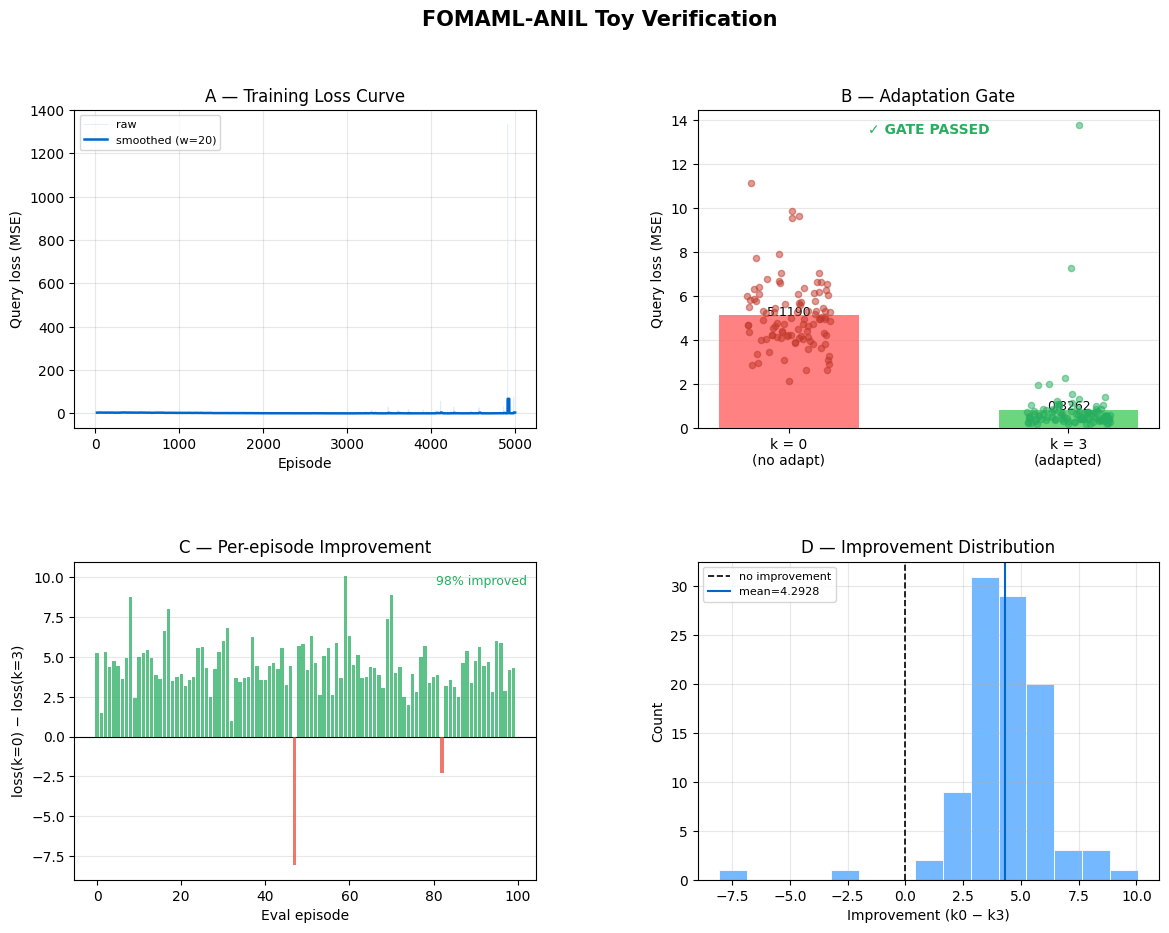

Saved: /home/theslender/coding_stuff/voice_fl/poc/notebooks/data/toy_full_summary.png


In [7]:
# ── Visualizations ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

os.makedirs(os.path.join(os.path.dirname(os.path.abspath("01_maml_toy_verify.ipynb")), "data"), exist_ok=True)
nb_dir = os.path.dirname(os.path.abspath("01_maml_toy_verify.ipynb"))

# ── Figure 1: Training convergence + gate summary (2×2 panels) ────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("FOMAML-ANIL Toy Verification", fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# Panel A — Training loss curve (smoothed)
ax_a = fig.add_subplot(gs[0, 0])
window = 20
smoothed = np.convolve(train_losses, np.ones(window) / window, mode="valid")
x_smooth = np.arange(window - 1, len(train_losses))
ax_a.plot(train_losses, color="#cce5ff", linewidth=0.7, label="raw", alpha=0.6)
ax_a.plot(x_smooth, smoothed, color="#0066cc", linewidth=1.8, label=f"smoothed (w={window})")
ax_a.set_xlabel("Episode")
ax_a.set_ylabel("Query loss (MSE)")
ax_a.set_title("A — Training Loss Curve")
ax_a.legend(fontsize=8)
ax_a.grid(True, alpha=0.3)

# Panel B — k=0 vs k=3 bar chart with individual episode jitter
ax_b = fig.add_subplot(gs[0, 1])
bar_x = [0, 1]
bar_means = [mean_k0, mean_k3]
bar_colors = ["#ff6b6b", "#51cf66"]
bars = ax_b.bar(bar_x, bar_means, color=bar_colors, width=0.5, zorder=3, alpha=0.85)
# scatter individual episodes
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.15, 0.15, len(k0_losses))
ax_b.scatter(jitter, k0_losses, color="#c0392b", s=20, alpha=0.5, zorder=4)
ax_b.scatter(1 + jitter, k3_losses, color="#27ae60", s=20, alpha=0.5, zorder=4)
ax_b.set_xticks([0, 1])
ax_b.set_xticklabels(["k = 0\n(no adapt)", "k = 3\n(adapted)"])
ax_b.set_ylabel("Query loss (MSE)")
ax_b.set_title("B — Adaptation Gate")
for bar, val in zip(bars, bar_means):
    ax_b.text(bar.get_x() + bar.get_width() / 2, val + 0.002, f"{val:.4f}", ha="center", fontsize=9)
gate_color = "#27ae60" if gate_passed else "#e74c3c"
gate_label = "✓ GATE PASSED" if gate_passed else "✗ GATE FAILED"
ax_b.text(0.5, 0.96, gate_label, transform=ax_b.transAxes, ha="center", va="top",
          fontsize=10, fontweight="bold", color=gate_color)
ax_b.grid(True, axis="y", alpha=0.3)

# Panel C — Per-episode improvement (k0 − k3)
ax_c = fig.add_subplot(gs[1, 0])
improvements = [k0 - k3 for k0, k3 in zip(k0_losses, k3_losses)]
colors_c = ["#27ae60" if v > 0 else "#e74c3c" for v in improvements]
ax_c.bar(range(len(improvements)), improvements, color=colors_c, alpha=0.75, zorder=3)
ax_c.axhline(0, color="black", linewidth=0.8)
ax_c.set_xlabel("Eval episode")
ax_c.set_ylabel("loss(k=0) − loss(k=3)")
ax_c.set_title("C — Per-episode Improvement")
ax_c.grid(True, axis="y", alpha=0.3)
pct_positive = sum(1 for v in improvements if v > 0) / len(improvements) * 100
ax_c.text(0.98, 0.96, f"{pct_positive:.0f}% improved",
          transform=ax_c.transAxes, ha="right", va="top", fontsize=9, color="#27ae60")

# Panel D — Improvement distribution histogram
ax_d = fig.add_subplot(gs[1, 1])
ax_d.hist(improvements, bins=15, color="#74b9ff", edgecolor="white", linewidth=0.6)
ax_d.axvline(0, color="black", linewidth=1.2, linestyle="--", label="no improvement")
ax_d.axvline(float(np.mean(improvements)), color="#0066cc", linewidth=1.5,
             linestyle="-", label=f"mean={np.mean(improvements):.4f}")
ax_d.set_xlabel("Improvement (k0 − k3)")
ax_d.set_ylabel("Count")
ax_d.set_title("D — Improvement Distribution")
ax_d.legend(fontsize=8)
ax_d.grid(True, alpha=0.3)

save_path = os.path.join(nb_dir, "data", "toy_full_summary.png")
plt.savefig(save_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")
